In [ ]:
import os
from dotenv import load_dotenv

load_dotenv()

In [7]:
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [ ]:
from langchain_groq import ChatGroq
model=ChatGroq(model="qwen/qwen3-32b")
model

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000022F66A558B0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000022F66A55DC0>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [10]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display


In [11]:
# Graph State
class State(TypedDict):
    topic: str
    result: str


In [23]:
def generate_blog(state: State):
    """ LLM call to generate the Blog."""

    msg = model.invoke(f"Write a blog about the  {state['topic']}")

    return {"result":msg.content}

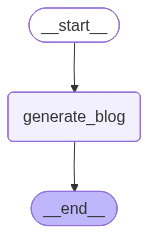

In [24]:
workflow = StateGraph(State)

# Add Note
workflow.add_node("generate_blog", generate_blog)

workflow.add_edge(START, "generate_blog")
workflow.add_edge("generate_blog", END)

chain=workflow.compile()

display(Image(chain.get_graph().draw_mermaid_png()))

In [25]:
# WorkFlow
state = chain.invoke({"topic": "Blog about Langgraph"})

In [28]:
print(state['result'])

<think>
Okay, the user wants me to write a blog about LangGraph. First, I need to recall what LangGraph is. I think it's a framework for building applications using language models, maybe with a focus on graph-based workflows. But I'm not 100% sure. Let me start by checking some details to make sure I get the basics right.

So, LangGraph is part of the LangChain ecosystem, right? LangChain has different modules like LangChain Core, LangChain Agents, and then maybe LangGraph for structuring workflows. The key idea is to use a graph structure to manage the flow of data and control between different components. That makes sense because traditional linear flows might not be enough for complex applications.

The user might be a developer or someone interested in building AI-powered applications. They probably want to understand what LangGraph is, how it works, and why it's useful compared to other tools. They might also be looking for examples or use cases to see how it can be applied in re